# Esplorazione UMAP / t-SNE + clustering k-means

Notebook esplorativo: proviamo **UMAP** e **t-SNE** con diverse metriche/parametri sulla stessa matrice lesionale voxel-wise (`data/derived/lesion_matrix/21-07_s1.1`, 1150 soggetti), clusterizzando ogni embedding 2D con **k-means** (metodo di clustering fissato in questa fase, non ancora messo a confronto con altri metodi).

Per ogni combinazione: parametri usati + tempo di calcolo, scatter dell'embedding grezzo, curve di tuning k-means (silhouette / Calinski-Harabasz / Davies-Bouldin / inertia su una griglia di k) ed embedding clusterizzato.

Contesto/letteratura di riferimento: 
- [`assets/knowledge/dimensionality_reduction_methods.md`](../assets/knowledge/dimensionality_reduction_methods.md), 
- [`assets/knowledge/used_dim_reduction_methods.md`](../assets/knowledge/used_dim_reduction_methods.md); 
- studio di tuning già fatto su questa stessa matrice (solo metrica Euclidea di default): [`results/lesion/dim_reduction_clustering/TUNING_ANALYSIS.md`](../results/lesion/dim_reduction_clustering/TUNING_ANALYSIS.md).

> **Perché testare metriche diverse dall'Euclidea di default**: i dati sono maschere di lesione binarie (0/1), molto sparse (~1.7% di voxel accesi). Su vettori binari sparsi la distanza Euclidea (equivalente qui a una distanza di Hamming, non normalizzata) è dominata dal **volume della lesione** più che dalla sua posizione — verificato empiricamente nello studio di tuning citato sopra: una componente PCA correla r=0.92 col volume lesionale. Qui aggiungiamo **Jaccard** e **Dice** (metriche standard per l'overlap di maschere binarie, normalizzate per la dimensione di ciascuna lesione) e il **coseno**, per vedere se la struttura trovata cambia.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 0

/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Caricamento dati + statistiche di base

In [2]:
DATA_DIR = Path("../data/derived/lesion_matrix/21-07_s1.1")

X = np.load(DATA_DIR / "matrix.npy")
metadata = pd.read_csv(DATA_DIR / "metadata.csv")

print(f"matrix shape: {X.shape[0]} soggetti x {X.shape[1]} feature (voxel)")
print(f"dtype: {X.dtype}, valori unici: {np.unique(X)}")
print(f"frazione di voxel 'accesi' (lesionati) sul totale: {X.mean():.4f}")

per_subject = X.sum(axis=1)
print(
    f"\nvoxel lesionati per soggetto: min={per_subject.min()}, mediana={np.median(per_subject):.0f}, "
    f"media={per_subject.mean():.1f}, max={per_subject.max()}"
)

per_voxel = X.sum(axis=0)
print(f"soggetti per voxel: min={per_voxel.min()}, mediana={np.median(per_voxel):.0f}, max={per_voxel.max()}")
print(f"quota di voxel lesionati in <1% dei soggetti: {(per_voxel < 0.01 * X.shape[0]).mean():.2%}")

print("\nsoggetti per dataset:")
print(metadata["dataset"].value_counts())

matrix shape: 1150 soggetti x 254865 feature (voxel)
dtype: uint8, valori unici: [0 1]
frazione di voxel 'accesi' (lesionati) sul totale: 0.0174

voxel lesionati per soggetto: min=1, mediana=2010, media=4424.3, max=41646
soggetti per voxel: min=1, mediana=7, max=180
quota di voxel lesionati in <1% dei soggetti: 58.08%

soggetti per dataset:
dataset
UKLFR/stroke_UKLFR    697
UNIPD/WashU           202
UNIPD/PSP             168
UNIPD/PASPORT          83
Name: count, dtype: int64


## Distanze precalcolate (Jaccard, Dice, coseno)

Jaccard/Dice/coseno richiedono confrontare ogni coppia di soggetti. Farlo con `scipy.spatial.distance.pdist` su 254.865 feature binarie è troppo lento (~19 minuti stimati per singola metrica, testato su un sottoinsieme). Le ricalcoliamo qui in forma vettorizzata: essendo i dati binari, l'overlap tra due soggetti è un prodotto matriciale (`X @ X.T`), da cui Jaccard e Dice si ricavano in poche operazioni — pochi secondi invece di minuti, via BLAS. Stesso trucco per il coseno (prodotto scalare tra righe normalizzate). Le passiamo poi a UMAP/t-SNE come matrice di distanza precalcolata (`metric="precomputed"`); l'Euclidea resta invece calcolata internamente dalla libreria (comportamento di default, già quello usato in produzione).

In [3]:
Xf = X.astype(np.float32)

assert per_subject.min() > 0, "ci sono soggetti senza alcun voxel lesionato: union potrebbe essere 0"

intersection = Xf @ Xf.T
lesion_size = Xf.sum(axis=1)
union = lesion_size[:, None] + lesion_size[None, :] - intersection

jaccard_dist = 1 - intersection / union
dice_dist = 1 - (2 * intersection) / (lesion_size[:, None] + lesion_size[None, :])
np.fill_diagonal(jaccard_dist, 0.0)
np.fill_diagonal(dice_dist, 0.0)

norm_X = Xf / np.linalg.norm(Xf, axis=1, keepdims=True)
cosine_dist = 1 - norm_X @ norm_X.T
np.fill_diagonal(cosine_dist, 0.0)

print("jaccard_dist range:", jaccard_dist.min(), jaccard_dist.max())
print("dice_dist range:", dice_dist.min(), dice_dist.max())
print("cosine_dist range:", cosine_dist.min(), cosine_dist.max())

jaccard_dist range: 0.0 1.0
dice_dist range: 0.0 1.0
cosine_dist range: 0.0 1.0


## Parametri da esplorare

**UMAP**
- `metric`: "euclidean" (usa `Xf`) · "cosine"/"jaccard"/"dice" (usa la matrice precalcolata corrispondente, con `metric="precomputed"`)
- `n_neighbors`: 5 (default progetto) · 15 (default libreria) · 30 · 50 — più basso = struttura più locale/frammentata, più alto = più globale/smussata
- `min_dist`: 0.0 (default progetto, cluster compatti) · 0.1 (default libreria) · 0.5 (punti più distanziati)

**t-SNE**
- `metric`: "euclidean" (usa `Xf`, `method` di default va bene) · "cosine"/"jaccard"/"dice" (usa la matrice precalcolata, richiede `method="exact"` e `init="random"`)
- `perplexity`: 30 (default progetto, ~1150 soggetti) · 50 · 100 — indicativamente il numero di vicini effettivi considerati per punto
- `early_exaggeration`, `learning_rate`, `max_iter`: lasciali ai default progetto (12, 200, 1000) a meno che tu non voglia esplorare anche quelli

**k-means**
- `n_clusters`: prova 2, 3, 4, 5, 6, 8, 10 — nessun tuning automatico, cambi il numero e rilanci la cella


## Helper: tuning k-means + plot

`K_GRID` è la stessa griglia usata dal registry di produzione (`config/registry/params_clustering.json`, `kmeans.tuning_grid`). Il k-means gira sempre sull'embedding 2D (coordinate Euclidee in output, qualunque sia stata la metrica usata a monte per costruire l'embedding) — mai sulle matrici di distanza precalcolate, che servono solo a UMAP/t-SNE.

In [6]:
K_GRID = [2, 3, 4, 5, 6, 8, 10]


def kmeans_tuning_sweep(X_2d: np.ndarray, k_grid: list) -> pd.DataFrame:
    rows = []
    for k in k_grid:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto").fit(X_2d)
        labels = km.labels_
        rows.append({
            "k": k,
            "silhouette": silhouette_score(X_2d, labels),
            "calinski_harabasz": calinski_harabasz_score(X_2d, labels),
            "davies_bouldin": davies_bouldin_score(X_2d, labels),
            "inertia": km.inertia_,
        })
    return pd.DataFrame(rows)


def plot_tuning_metrics(df: pd.DataFrame, title: str) -> None:
    metrics = ["silhouette", "calinski_harabasz", "davies_bouldin", "inertia"]
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, metric in zip(axes.ravel(), metrics):
        ax.plot(df["k"], df[metric], marker="o")
        ax.set_xlabel("k")
        ax.set_ylabel(metric)
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout()
    plt.show()


def plot_embedding(emb: np.ndarray, title: str, labels: np.ndarray = None) -> None:
    fig, ax = plt.subplots(figsize=(6, 5))
    if labels is None:
        ax.scatter(emb[:, 0], emb[:, 1], s=12, alpha=0.6)
    else:
        sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=labels, palette="tab10", s=20, ax=ax, legend="full")
        ax.legend(title="cluster", loc="upper left", bbox_to_anchor=(1.02, 1.0))
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")
    ax.set_title(title, fontweight="bold")
    plt.show()


def explore_embedding(emb: np.ndarray, label: str, summary_rows: list) -> None:
    plot_embedding(emb, f"{label}\nembedding grezzo (non clusterizzato)")

    tuning_df = kmeans_tuning_sweep(emb, K_GRID)
    plot_tuning_metrics(tuning_df, f"{label}\nk-means tuning")

    best_row = tuning_df.loc[tuning_df["silhouette"].idxmax()]
    best_k = int(best_row["k"])
    labels = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init="auto").fit_predict(emb)
    plot_embedding(emb, f"{label}\nk-means k={best_k} (miglior silhouette nella griglia {K_GRID})", labels=labels)

    summary_rows.append({
        "config": label,
        "best_k_by_silhouette": best_k,
        "silhouette": best_row["silhouette"],
        "calinski_harabasz": best_row["calinski_harabasz"],
        "davies_bouldin": best_row["davies_bouldin"],
    })


summary_rows = []

## UMAP



/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


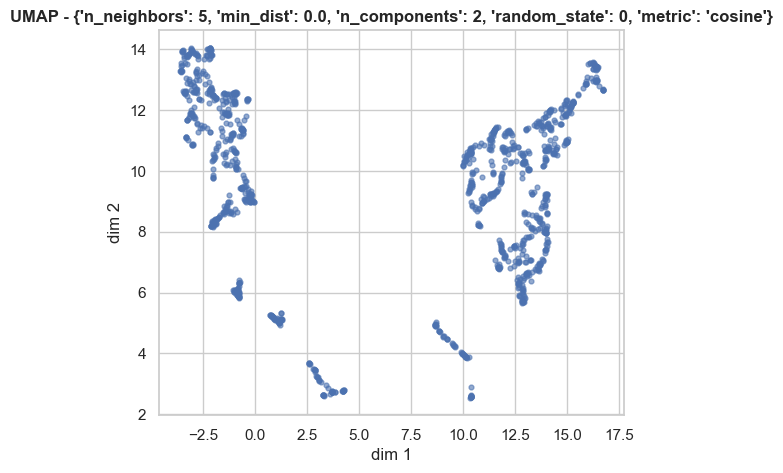

In [8]:
UMAP_PARAMS = {
    "n_neighbors": 5,
    "min_dist": 0.0,
    "n_components": 2,
    "random_state": RANDOM_STATE,
    "metric": "cosine",  # euclidean -> UMAP_INPUT = Xf; altrimenti cosine_dist/jaccard_dist/dice_dist + metric="precomputed"
}
UMAP_INPUT = Xf

umap_embedding = umap.UMAP(**UMAP_PARAMS).fit_transform(UMAP_INPUT)
plot_embedding(umap_embedding, f"UMAP - {UMAP_PARAMS}")


In [ ]:
N_CLUSTERS_UMAP = 4

umap_labels = KMeans(n_clusters=N_CLUSTERS_UMAP, random_state=RANDOM_STATE, n_init="auto").fit_predict(umap_embedding)
plot_embedding(umap_embedding, f"UMAP - {UMAP_PARAMS} - kmeans k={N_CLUSTERS_UMAP}", labels=umap_labels)


## t-SNE



In [ ]:
TSNE_PARAMS = {
    "n_components": 2,
    "early_exaggeration": 12,
    "learning_rate": 200,
    "max_iter": 1000,
    "random_state": RANDOM_STATE,
    "perplexity": 30,
    "metric": "jaccard",  # euclidean -> TSNE_INPUT = Xf; per cosine/jaccard/dice aggiungi anche method="exact", init="random"
}
TSNE_INPUT = Xf

tsne_embedding = TSNE(**TSNE_PARAMS).fit_transform(TSNE_INPUT)
plot_embedding(tsne_embedding, f"t-SNE - {TSNE_PARAMS}")


In [ ]:
N_CLUSTERS_TSNE = 4

tsne_labels = KMeans(n_clusters=N_CLUSTERS_TSNE, random_state=RANDOM_STATE, n_init="auto").fit_predict(tsne_embedding)
plot_embedding(tsne_embedding, f"t-SNE - {TSNE_PARAMS} - kmeans k={N_CLUSTERS_TSNE}", labels=tsne_labels)


## Confronto riassuntivo

In [ ]:
summary_df = pd.DataFrame(summary_rows).sort_values("silhouette", ascending=False).reset_index(drop=True)
summary_df

**Da tenere a mente leggendo questa tabella**: il `k` riportato per ogni configurazione è solo il massimo di silhouette nella griglia testata (2, 3, 4, 5, 6, 8, 10) — una scorciatoia per avere qualcosa di sensato da visualizzare, non una selezione da portare in produzione (stessa filosofia di [`TUNING_ANALYSIS.md`](../results/lesion/dim_reduction_clustering/TUNING_ANALYSIS.md): nessuna scelta automatica silenziosa, la decisione resta umana). Le metriche Jaccard/Dice/coseno qui non sono ancora state validate in quello studio (che usava solo la metrica Euclidea di default) — vanno lette come primo sguardo esplorativo, non come conclusione.